In [55]:
# ============================================================
# Jupyter Notebook 1セル完結：不等間隔(0..360deg)のNW補間
#   - NW naive（素朴 O(N*M)）
#   - NW fast（ビン化 + 周期FFT畳み込み：近似）
#   - サンプルデータ生成（L=256でN=300が欠損~50%になるように作る）
#   - 可視化、計算時間比較、簡単ベンチ
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter
from scipy.signal import fftconvolve
import pandas as pd
from IPython.display import display

# ----------------------------
# 1) 真の波形（周期 360deg）
# ----------------------------
def true_wave(deg):
    th = np.deg2rad(deg)
    base = 0.9*np.sin(th) + 0.35*np.sin(3*th + 0.7) + 0.18*np.cos(7*th - 0.2)
    bump = 0.6*np.exp(-0.5*((((deg-110+180)%360)-180)/9.0)**2)  # 110deg近辺
    return base + bump

# ----------------------------
# 2) サンプルデータ作成（不等間隔）
#   目的：L=256 にビン化したとき、N=300 で欠損がだいたい50%になるようにする
#   方法：観測が乗るビン集合を active_bins 個に限定して、その中だけでサンプルする
# ----------------------------
np.random.seed(0)

L_missing = 256   # 欠損率を作りたいビン数
N = 300           # 観測点数（不等間隔）
noise_std = 0.12  # ノイズ

# active_bins を調整すると欠損率が変わる（経験的に 150 くらいで欠損 ~ 0.5 になりやすい）
active_bins = 150

bins = np.random.choice(np.arange(L_missing), size=active_bins, replace=False)
bins.sort()

# 観測点の「所属ビン」を active_bins の中から選ぶ（偏りが欲しければ確率をいじる）
chosen_bins = np.random.choice(bins, size=N, replace=True)

# ビン内を一様にサンプルして角度に戻す
bin_w = 360.0 / L_missing
u = np.random.rand(N)
x_obs = (chosen_bins + u) * bin_w  # [0,360)

# 真値 + ノイズ
y_obs = true_wave(x_obs) + np.random.randn(N) * noise_std

# ソート（見やすさ用）
ordr = np.argsort(x_obs)
x_obs = x_obs[ordr]
y_obs = y_obs[ordr]

# 欠損率チェック（L=256のビンで、どれだけ空か）
idx_chk = np.floor(x_obs / 360.0 * L_missing).astype(int)
idx_chk = np.clip(idx_chk, 0, L_missing - 1)
occupied = np.unique(idx_chk).size
missing_ratio = 1.0 - occupied / L_missing
print(f"[check] L_missing={L_missing}, N={N}, occupied={occupied}, missing_ratio={missing_ratio:.3f}")

# 補間したい均一グリッド
M = 256
x_grid = np.linspace(0.0, 360.0, M, endpoint=False)

# ----------------------------
# 3) NW naive（素朴 O(N*M)）
#   周期距離（0と360が近い）を使う
# ----------------------------
def circular_distance_deg(a, b):
    d = (a[..., None] - b[None, ...] + 180.0) % 360.0 - 180.0
    return np.abs(d)

def nw_naive(x_obs, y_obs, x_query, h_deg, eps=1e-12):
    d = circular_distance_deg(x_query, x_obs)          # (M,N)
    w = np.exp(-0.5*(d / h_deg)**2)                    # (M,N)
    num = w @ y_obs                                    # (M,)
    den = w.sum(axis=1)                                # (M,)
    return num / (den + eps)

# ----------------------------
# 4) NW fast（近似）：ビン化 + 周期FFT畳み込み
# ----------------------------
def bin_sum_on_circle(x_obs, y_obs, Lbin):
    idx = np.floor(x_obs / 360.0 * Lbin).astype(int)
    idx = np.clip(idx, 0, Lbin-1)
    num_bin = np.zeros(Lbin, dtype=float)
    den_bin = np.zeros(Lbin, dtype=float)
    np.add.at(num_bin, idx, y_obs)
    np.add.at(den_bin, idx, 1.0)
    return num_bin, den_bin

def gaussian_kernel_on_circle(Lbin, h_deg):
    delta = 360.0 / Lbin
    k = np.arange(Lbin)
    kdist = np.minimum(k, Lbin - k)
    d_deg = kdist * delta
    ker = np.exp(-0.5*(d_deg / h_deg)**2)
    return ker

def circular_convolve_fft(a, b):
    L = len(a)
    full = fftconvolve(a, b, mode="full")  # 長さ 2L-1（線形畳み込み）
    c = full[:L].copy()
    c[:L-1] += full[L:]                    # 周期化（折り返し）
    return c

def nw_fast_fft(x_obs, y_obs, x_query, h_deg, Lbin=8192, eps=1e-12):
    num_bin, den_bin = bin_sum_on_circle(x_obs, y_obs, Lbin)
    ker = gaussian_kernel_on_circle(Lbin, h_deg)
    num_sm = circular_convolve_fft(num_bin, ker)
    den_sm = circular_convolve_fft(den_bin, ker)

    pos = (x_query / 360.0 * Lbin)
    i0 = np.floor(pos).astype(int) % Lbin
    i1 = (i0 + 1) % Lbin
    t = pos - np.floor(pos)
    num_q = (1.0 - t)*num_sm[i0] + t*num_sm[i1]
    den_q = (1.0 - t)*den_sm[i0] + t*den_sm[i1]
    return num_q / (den_q + eps)


[check] L_missing=256, N=300, occupied=131, missing_ratio=0.488


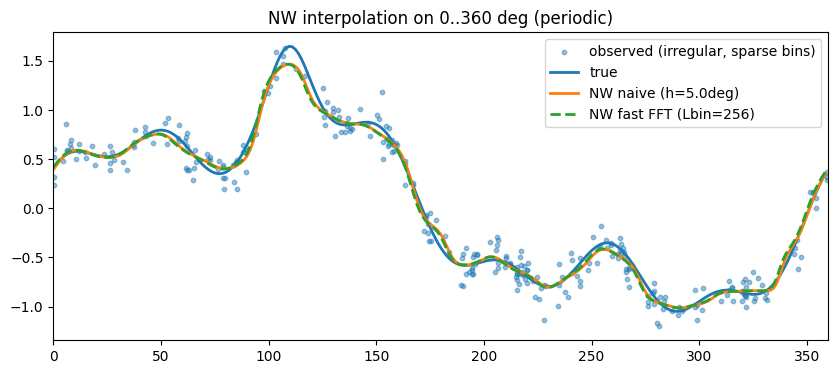

RMSE(naive vs fast) = 0.020075588335945062


In [56]:

# ----------------------------
# 5) 実行（可視化）
# ----------------------------
h_deg = 5.0      # 平滑化幅（度）
Lbin  = 256     # 高速版の内部格子

y_naive = nw_naive(x_obs, y_obs, x_grid, h_deg=h_deg)
y_fast  = nw_fast_fft(x_obs, y_obs, x_grid, h_deg=h_deg, Lbin=Lbin)

plt.figure(figsize=(10,4))
plt.scatter(x_obs, y_obs, s=10, alpha=0.45, label="observed (irregular, sparse bins)")
plt.plot(x_grid, true_wave(x_grid), linewidth=2, label="true")
plt.plot(x_grid, y_naive, linewidth=2, label=f"NW naive (h={h_deg}deg)")
plt.plot(x_grid, y_fast,  linewidth=2, linestyle="--", label=f"NW fast FFT (Lbin={Lbin})")
plt.xlim(0, 360)
plt.title("NW interpolation on 0..360 deg (periodic)")
plt.legend()
plt.show()

rmse = np.sqrt(np.mean((y_naive - y_fast)**2))
print("RMSE(naive vs fast) =", rmse)


In [57]:

# ----------------------------
# 6) 計算時間比較
# ----------------------------
def time_func(fn, n_repeat=5):
    ts = []
    out = None
    for _ in range(n_repeat):
        t0 = perf_counter()
        out = fn()
        t1 = perf_counter()
        ts.append(t1 - t0)
    ts = np.array(ts)
    return out, float(np.median(ts)), float(ts.min()), float(ts.max())

_ = nw_naive(x_obs, y_obs, x_grid, h_deg=h_deg)
_ = nw_fast_fft(x_obs, y_obs, x_grid, h_deg=h_deg, Lbin=Lbin)

_, med1, mn1, mx1 = time_func(lambda: nw_naive(x_obs, y_obs, x_grid, h_deg=h_deg), n_repeat=5)
_, med2, mn2, mx2 = time_func(lambda: nw_fast_fft(x_obs, y_obs, x_grid, h_deg=h_deg, Lbin=Lbin), n_repeat=5)

print("\n=== Timing (seconds) ===")
print(f"NW naive    : median={med1:.6f}, min={mn1:.6f}, max={mx1:.6f}")
print(f"NW fast FFT : median={med2:.6f}, min={mn2:.6f}, max={mx2:.6f}")
print("speedup ~", med1/med2)



=== Timing (seconds) ===
NW naive    : median=0.001796, min=0.001550, max=0.002008
NW fast FFT : median=0.000237, min=0.000230, max=0.000348
speedup ~ 7.57890294032192


In [58]:

# ----------------------------
# 7) 簡単ベンチ（条件を変える）
#   ここでも「L_missing=256で欠損~50%」の作り方を再利用
# ----------------------------
def make_sparse_irregular_data(N=300, L_missing=256, active_bins=150, noise_std=0.12, seed=0):
    rng = np.random.default_rng(seed)
    bins = rng.choice(np.arange(L_missing), size=active_bins, replace=False)
    bins.sort()
    chosen_bins = rng.choice(bins, size=N, replace=True)
    bin_w = 360.0 / L_missing
    x = (chosen_bins + rng.random(N)) * bin_w
    y = true_wave(x) + rng.standard_normal(N) * noise_std
    ordr = np.argsort(x)
    x = x[ordr]; y = y[ordr]

    idx = np.floor(x / 360.0 * L_missing).astype(int)
    idx = np.clip(idx, 0, L_missing-1)
    occ = np.unique(idx).size
    miss = 1.0 - occ / L_missing
    return x, y, miss, occ

def run_benchmark(N=300, M=1024, h_deg=3.0, Lbin=8192, L_missing=256, active_bins=150, noise_std=0.12, seed=0):
    x_obs, y_obs, miss, occ = make_sparse_irregular_data(
        N=N, L_missing=L_missing, active_bins=active_bins, noise_std=noise_std, seed=seed
    )
    x_grid = np.linspace(0.0, 360.0, M, endpoint=False)

    _ = nw_naive(x_obs, y_obs, x_grid, h_deg=h_deg)
    _ = nw_fast_fft(x_obs, y_obs, x_grid, h_deg=h_deg, Lbin=Lbin)

    y1, t1, _, _ = time_func(lambda: nw_naive(x_obs, y_obs, x_grid, h_deg=h_deg), n_repeat=3)
    y2, t2, _, _ = time_func(lambda: nw_fast_fft(x_obs, y_obs, x_grid, h_deg=h_deg, Lbin=Lbin), n_repeat=3)

    rmse = float(np.sqrt(np.mean((y1 - y2)**2)))
    return {
        "N":N, "M":M, "h_deg":h_deg, "Lbin":Lbin,
        "L_missing":L_missing, "active_bins":active_bins,
        "occupied_bins":occ, "missing_ratio":miss,
        "t_naive":t1, "t_fast":t2, "speedup":t1/t2, "rmse":rmse
    }

cases = [
    (300, 1024, 3.0, 8192, 256, 150),
    (300, 2048, 3.0, 8192, 256, 150),
    (300, 2048, 2.0, 16384, 256, 150),
    (300, 1024, 3.0, 4096, 256, 140),
]

df = pd.DataFrame([run_benchmark(*c, noise_std=0.12, seed=0) for c in cases])
print("\n=== Benchmark table ===")
display(df)


=== Benchmark table ===


,N,M,h_deg,Lbin,L_missing,active_bins,occupied_bins,missing_ratio,t_naive,t_fast,speedup,rmse
0,300,1024,3.0,8192,256,150,124,0.515625,0.011276,0.001065,10.588600,0.000712
1,300,2048,3.0,8192,256,150,124,0.515625,0.022787,0.000988,23.052504,0.000712
2,300,2048,2.0,16384,256,150,124,0.515625,0.023455,0.001980,11.844814,0.000438
3,300,1024,3.0,4096,256,140,122,0.523438,0.011210,0.000602,18.611489,0.001339


## 高速NW法


In [59]:
# ============================================================
# 1セル完結：サンプル windows（辞書形式）を作って nw_fast_fft を試す
#   windows[i] = {"meta": ..., "data": array(n,2)=(deg,value)}
#   - 点数 n は 250〜350 程度でバラバラ
#   - L=256 にビン化したとき欠損がそこそこ出る（例：~50%付近）
#   - 補間は 256 点、ビンも 256（L_out=256, Lbin=256）
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from time import perf_counter

# ----------------------------
# 真の波形（周期 360deg）
# ----------------------------
def true_wave(deg):
    th = np.deg2rad(deg)
    base = 0.9*np.sin(th) + 0.35*np.sin(3*th + 0.7) + 0.18*np.cos(7*th - 0.2)
    bump = 0.6*np.exp(-0.5*((((deg-110+180)%360)-180)/9.0)**2)
    return base + bump

# ============================================================
# NW naive（参考：遅い）
# ============================================================
def circular_distance_deg(a, b):
    d = (a[..., None] - b[None, ...] + 180.0) % 360.0 - 180.0
    return np.abs(d)

def nw_naive(x_obs, y_obs, x_query, h_deg, eps=1e-12):
    d = circular_distance_deg(x_query, x_obs)          # (M,N)
    w = np.exp(-0.5*(d / h_deg)**2)                    # (M,N)
    num = w @ y_obs
    den = w.sum(axis=1)
    return num / (den + eps)

# ============================================================
# NW fast（ビン化 + 周期FFT畳み込み：近似）
# ============================================================
def bin_sum_on_circle(x_obs, y_obs, Lbin):
    idx = np.floor((x_obs % 360.0) / 360.0 * Lbin).astype(int)
    idx = np.clip(idx, 0, Lbin-1)
    num_bin = np.zeros(Lbin, dtype=float)
    den_bin = np.zeros(Lbin, dtype=float)
    np.add.at(num_bin, idx, y_obs)
    np.add.at(den_bin, idx, 1.0)
    return num_bin, den_bin

def gaussian_kernel_on_circle(Lbin, h_deg):
    delta = 360.0 / Lbin
    k = np.arange(Lbin)
    kdist = np.minimum(k, Lbin - k)
    d_deg = kdist * delta
    ker = np.exp(-0.5*(d_deg / h_deg)**2)
    return ker

def circular_convolve_fft(a, b):
    L = len(a)
    full = fftconvolve(a, b, mode="full")  # 長さ 2L-1（線形畳み込み）
    c = full[:L].copy()
    c[:L-1] += full[L:]                    # 周期化（折り返し）
    return c

def nw_fast_fft(x_obs, y_obs, x_query, h_deg, Lbin=256, eps=1e-12):
    num_bin, den_bin = bin_sum_on_circle(x_obs, y_obs, Lbin)
    ker = gaussian_kernel_on_circle(Lbin, h_deg)
    num_sm = circular_convolve_fft(num_bin, ker)
    den_sm = circular_convolve_fft(den_bin, ker)

    pos = (x_query % 360.0) / 360.0 * Lbin
    i0 = np.floor(pos).astype(int) % Lbin
    i1 = (i0 + 1) % Lbin
    t = pos - np.floor(pos)

    num_q = (1.0 - t)*num_sm[i0] + t*num_sm[i1]
    den_q = (1.0 - t)*den_sm[i0] + t*den_sm[i1]
    return num_q / (den_q + eps)

# ============================================================
# windows（辞書）に適用するラッパ
# ============================================================
def apply_nw_fast_to_window(w, h_deg, L_out=256, Lbin=256, eps=1e-12):
    data = np.asarray(w["data"], float)

    x_grid = np.linspace(0.0, 360.0, L_out, endpoint=False)

    if data.size == 0:
        y_grid = np.full(L_out, np.nan, float)
        return {"meta": w["meta"], "x_grid": x_grid, "y_grid": y_grid}

    x_obs = data[:, 0] % 360.0
    y_obs = data[:, 1]
    ok = np.isfinite(x_obs) & np.isfinite(y_obs)
    x_obs = x_obs[ok]
    y_obs = y_obs[ok]

    if x_obs.size == 0:
        y_grid = np.full(L_out, np.nan, float)
        return {"meta": w["meta"], "x_grid": x_grid, "y_grid": y_grid}

    y_grid = nw_fast_fft(x_obs, y_obs, x_grid, h_deg=h_deg, Lbin=Lbin, eps=eps)
    return {"meta": w["meta"], "x_grid": x_grid, "y_grid": y_grid}

def apply_nw_fast_to_windows(windows, h_deg, L_out=256, Lbin=256, eps=1e-12):
    return [apply_nw_fast_to_window(w, h_deg, L_out=L_out, Lbin=Lbin, eps=eps) for w in windows]

# ============================================================
# サンプル windows 作成
#   - n点は 250〜350 程度でランダム
#   - L=256 のビンのうち active_bins 個だけで観測が起きるようにして欠損を作る
# ============================================================
def make_one_window(window_id, n_min=250, n_max=350,
                    L_missing=256, active_bins=150,
                    noise_std=0.3, seed=0):
    rng = np.random.default_rng(seed + window_id)

    n = int(rng.integers(n_min, n_max+1))

    active = rng.choice(np.arange(L_missing), size=active_bins, replace=False)
    active.sort()
    chosen_bins = rng.choice(active, size=n, replace=True)

    bin_w = 360.0 / L_missing
    x = (chosen_bins + rng.random(n)) * bin_w
    x = x % 360.0

    # 例として窓ごとに少し上下ズレを入れる
    offset = 0.20 * rng.standard_normal()
    y = true_wave(x) + offset + rng.standard_normal(n) * noise_std

    # ソート
    order = np.argsort(x)
    x = x[order]
    y = y[order]

    data = np.column_stack([x, y])

    # 欠損率（L_missing=256 のビンで空の割合）
    idx = np.floor(x / 360.0 * L_missing).astype(int)
    idx = np.clip(idx, 0, L_missing-1)
    occ = np.unique(idx).size
    missing_ratio = 1.0 - occ / L_missing

    meta = {
        "window_id": window_id,
        "n_points": n,
        "active_bins": active_bins,
        "occupied_bins": int(occ),
        "missing_ratio_L256": float(missing_ratio),
        "offset": float(offset),
    }
    return {"meta": meta, "data": data}

# windows を作成
np.random.seed(0)
n_windows = 8
windows = [make_one_window(i, active_bins=150, seed=100) for i in range(n_windows)]

print("windows[0].keys() =", windows[0].keys())
print("windows[0]['data'].shape =", windows[0]["data"].shape)
print("例：missing_ratio_L256（各window）")
for w in windows:
    m = w["meta"]["missing_ratio_L256"]
    print(f"  id={w['meta']['window_id']:2d}  n={w['meta']['n_points']:3d}  missing={m:.3f}")


windows[0].keys() = dict_keys(['meta', 'data'])
windows[0]['data'].shape = (327, 2)
例：missing_ratio_L256（各window）
  id= 0  n=327  missing=0.469
  id= 1  n=281  missing=0.496
  id= 2  n=294  missing=0.500
  id= 3  n=305  missing=0.484
  id= 4  n=321  missing=0.484
  id= 5  n=278  missing=0.488
  id= 6  n=305  missing=0.500
  id= 7  n=260  missing=0.527


In [60]:

# ============================================================
# 適用（補間256点、ビン256）
# ============================================================
h_deg = 10.0
L_out = 256
Lbin  = 256

t0 = perf_counter()
windows_out = apply_nw_fast_to_windows(windows, h_deg=h_deg, L_out=L_out, Lbin=Lbin)
t1 = perf_counter()

Y = np.stack([w["y_grid"] for w in windows_out], axis=0)  # (n_windows, 256)
print("\nY.shape =", Y.shape, "  elapsed =", (t1 - t0), "sec")



Y.shape = (8, 256)   elapsed = 0.0029080000022077 sec


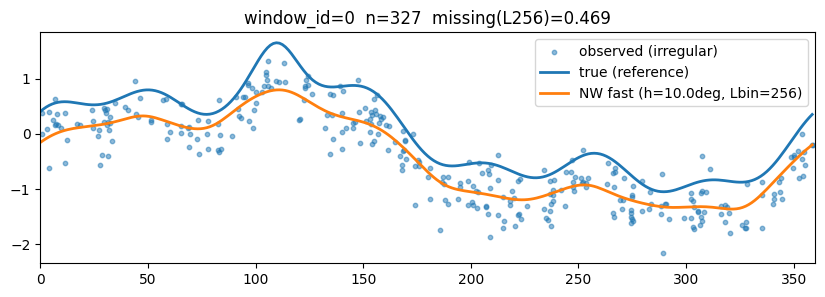

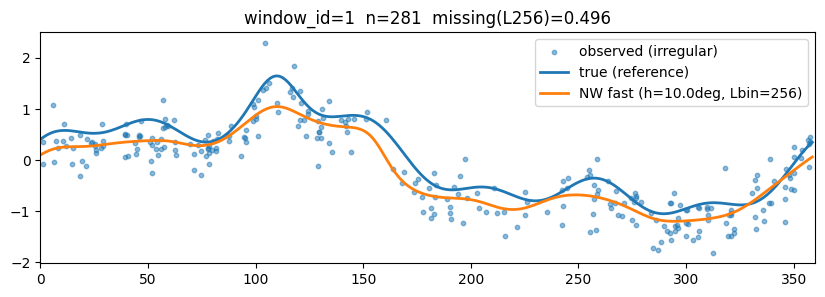

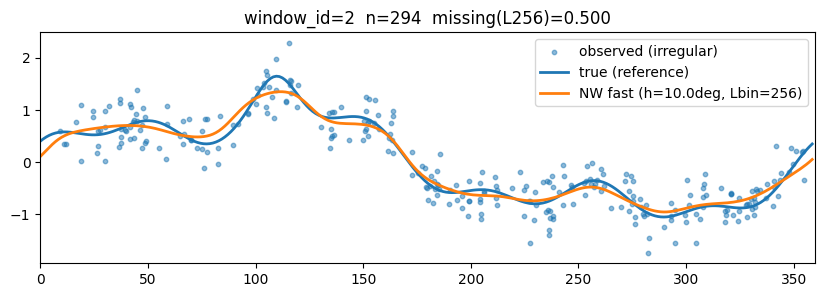

In [61]:

# ============================================================
# 可視化：いくつか表示
# ============================================================
x_grid = windows_out[0]["x_grid"]

for i in range(min(3, n_windows)):
    w = windows[i]
    wo = windows_out[i]
    x_obs = w["data"][:,0]
    y_obs = w["data"][:,1]

    plt.figure(figsize=(10,3))
    plt.scatter(x_obs, y_obs, s=10, alpha=0.5, label="observed (irregular)")
    plt.plot(x_grid, true_wave(x_grid), linewidth=2, label="true (reference)")
    plt.plot(x_grid, wo["y_grid"], linewidth=2, label=f"NW fast (h={h_deg}deg, Lbin={Lbin})")
    plt.xlim(0, 360)
    plt.title(f"window_id={w['meta']['window_id']}  n={w['meta']['n_points']}  missing(L256)={w['meta']['missing_ratio_L256']:.3f}")
    plt.legend()
    plt.show()


In [62]:

# ============================================================
# 参考：naive と比較したい場合（1 windowだけ）
# ============================================================
i = 0
x_obs = windows[i]["data"][:,0]
y_obs = windows[i]["data"][:,1]
y_naive = nw_naive(x_obs, y_obs, x_grid, h_deg=h_deg)
rmse = np.sqrt(np.mean((y_naive - windows_out[i]["y_grid"])**2))
print("RMSE(naive vs fast) for window 0 =", rmse)

RMSE(naive vs fast) for window 0 = 0.013371515491585167


周期スプラインとの比較

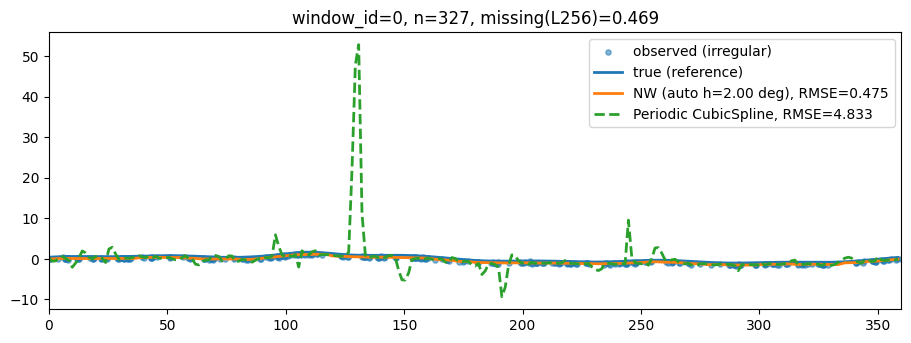

,n_windows,L_out,NW_time_total_sec,Spline_time_total_sec,NW_time_per_window_ms,Spline_time_per_window_ms,NW_RMSE_mean,Spline_RMSE_mean,NW_h_deg_used_mean,NW_h_deg_used_std
0,50,256,0.11526,0.022583,2.305196,0.451664,0.196582,157.467316,2.0,0.0


In [63]:
# ============================================================
# 不等間隔(0..360deg)の「NW回帰」と「周期スプライン」を
# 波形形状（真値との誤差）と計算時間で比較するサンプル（既存関数優先）
#
# 使う既存関数：
#   - SciPy: CubicSpline(bc_type="periodic")  … 周期スプライン（補間）
#   - NumPy: ベクトル化でNW回帰（SciPyにNW回帰の定番1関数が無いので最小実装）
#
# データ形式：
#   windows[i] = {"meta": ..., "data": array(n,2)=(deg,value)}
#   n は 250〜350 くらいでバラバラ、L=256で欠損がそこそこ出るように作る
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter
from scipy.interpolate import CubicSpline

# ----------------------------
# 0) 真の波形（周期 360deg）
# ----------------------------
def true_wave(deg):
    deg = np.asarray(deg) % 360.0
    th = np.deg2rad(deg)
    base = 0.9*np.sin(th) + 0.35*np.sin(3*th + 0.7) + 0.18*np.cos(7*th - 0.2)
    bump = 0.6*np.exp(-0.5*((((deg-110+180)%360)-180)/9.0)**2)
    return base + bump

# ----------------------------
# 1) サンプル windows 作成
#   L=256 のビンのうち active_bins 個でしか観測が起きないようにして欠損を作る
# ----------------------------
def make_one_window(window_id, n_min=250, n_max=350, L=256, active_bins=150, noise_std=0.12, seed=0):
    rng = np.random.default_rng(seed + window_id)
    n = int(rng.integers(n_min, n_max + 1))

    active = rng.choice(np.arange(L), size=active_bins, replace=False)
    chosen_bins = rng.choice(active, size=n, replace=True)

    bin_w = 360.0 / L
    x = (chosen_bins + rng.random(n)) * bin_w
    x = x % 360.0
    x.sort()

    offset = 0.20 * rng.standard_normal()
    y = true_wave(x) + offset + rng.standard_normal(n) * noise_std

    data = np.column_stack([x, y])

    idx = np.floor(x / 360.0 * L).astype(int)
    idx = np.clip(idx, 0, L-1)
    occ = np.unique(idx).size
    miss = 1.0 - occ / L

    meta = {
        "window_id": int(window_id),
        "n_points": int(n),
        "occupied_bins_L256": int(occ),
        "missing_ratio_L256": float(miss),
        "offset": float(offset),
    }
    return {"meta": meta, "data": data}

np.random.seed(0)
n_windows = 50
windows = [make_one_window(i, L=256, active_bins=150, seed=100) for i in range(n_windows)]

# ----------------------------
# 2) 出力グリッド（256点）
# ----------------------------
L_out = 256
x_grid = np.linspace(0.0, 360.0, L_out, endpoint=False)
y_true_grid = true_wave(x_grid)

# ----------------------------
# 3) NW回帰（最小実装：ベクトル化）
#   SciPyに「NW回帰の標準1関数」が無いので、既存関数で置き換えにくい部分だけ最小で書く
# ----------------------------
def auto_h_from_gaps(x_obs, scale=2.5, min_deg=2.0, max_deg=30.0):
    x = np.sort(np.asarray(x_obs) % 360.0)
    if x.size < 2:
        return min_deg
    gaps = np.diff(np.r_[x, x[0] + 360.0])     # wrap込み
    h = scale * float(np.median(gaps))
    h = max(h, min_deg)
    h = min(h, max_deg)
    return float(h)

def nw_gaussian_circular(x_obs, y_obs, x_query, h_deg=None, eps=1e-12):
    x_obs = np.asarray(x_obs) % 360.0
    y_obs = np.asarray(y_obs)
    x_query = np.asarray(x_query) % 360.0

    if h_deg is None:
        h_deg = auto_h_from_gaps(x_obs)

    # 周期距離（最短角距離）
    d = (x_query[:, None] - x_obs[None, :] + 180.0) % 360.0 - 180.0
    d = np.abs(d)

    w = np.exp(-0.5 * (d / h_deg)**2)
    num = w @ y_obs
    den = w.sum(axis=1)
    return num / (den + eps), float(h_deg)

# ----------------------------
# 4) 周期スプライン（既存関数）
#   CubicSpline(bc_type="periodic") を使う
#   端点一致が必要なので、(x0+360, y0) を足して周期条件を満たす
# ----------------------------
def periodic_cubic_spline(x_obs, y_obs, x_query):
    x_obs = np.asarray(x_obs) % 360.0
    y_obs = np.asarray(y_obs)
    order = np.argsort(x_obs)
    x = x_obs[order]
    y = y_obs[order]

    # 厳密にはxの重複があるとスプラインが壊れるので、同一xがあれば平均で潰す
    # （不等間隔データでたまに起きる対策）
    xu, inv = np.unique(x, return_inverse=True)
    if xu.size != x.size:
        y_sum = np.zeros_like(xu, dtype=float)
        y_cnt = np.zeros_like(xu, dtype=float)
        np.add.at(y_sum, inv, y)
        np.add.at(y_cnt, inv, 1.0)
        x = xu
        y = y_sum / np.maximum(y_cnt, 1.0)

    # 周期条件用に最後に1点追加
    x_ext = np.r_[x, x[0] + 360.0]
    y_ext = np.r_[y, y[0]]

    cs = CubicSpline(x_ext, y_ext, bc_type="periodic")
    return cs(np.asarray(x_query))

# ----------------------------
# 5) 形状比較（例：window 0）
# ----------------------------
w0 = windows[0]
x0 = w0["data"][:, 0]
y0 = w0["data"][:, 1]

y_nw0, h_used0 = nw_gaussian_circular(x0, y0, x_grid, h_deg=None)
y_sp0 = periodic_cubic_spline(x0, y0, x_grid)

rmse_nw0 = float(np.sqrt(np.mean((y_nw0 - y_true_grid)**2)))
rmse_sp0 = float(np.sqrt(np.mean((y_sp0 - y_true_grid)**2)))

plt.figure(figsize=(11, 3.6))
plt.scatter(x0, y0, s=14, alpha=0.55, label="observed (irregular)")
plt.plot(x_grid, y_true_grid, linewidth=2, label="true (reference)")
plt.plot(x_grid, y_nw0, linewidth=2, label=f"NW (auto h={h_used0:.2f} deg), RMSE={rmse_nw0:.3f}")
plt.plot(x_grid, y_sp0, linewidth=2, linestyle="--", label=f"Periodic CubicSpline, RMSE={rmse_sp0:.3f}")
plt.xlim(0, 360)
plt.title(f"window_id={w0['meta']['window_id']}, n={w0['meta']['n_points']}, missing(L256)={w0['meta']['missing_ratio_L256']:.3f}")
plt.legend()
plt.show()

# ----------------------------
# 6) 計算時間比較（複数windowで平均）
# ----------------------------
def time_many_windows(windows, fn):
    t0 = perf_counter()
    outs = [fn(w) for w in windows]
    t1 = perf_counter()
    return outs, (t1 - t0)

def fn_nw(w):
    x = w["data"][:, 0]
    y = w["data"][:, 1]
    yhat, h_used = nw_gaussian_circular(x, y, x_grid, h_deg=None)
    return yhat, h_used

def fn_spline(w):
    x = w["data"][:, 0]
    y = w["data"][:, 1]
    yhat = periodic_cubic_spline(x, y, x_grid)
    return yhat

# warm-up（初回の遅さを避ける）
_ = fn_nw(windows[0])
_ = fn_spline(windows[0])

(nw_out, t_nw) = time_many_windows(windows, fn_nw)
(sp_out, t_sp) = time_many_windows(windows, fn_spline)

# 形状（真値RMSE）もwindow平均で比較
rmse_nw = []
rmse_sp = []
h_list = []
for i, w in enumerate(windows):
    yhat_nw, h_used = nw_out[i]
    yhat_sp = sp_out[i]
    rmse_nw.append(np.sqrt(np.mean((yhat_nw - y_true_grid)**2)))
    rmse_sp.append(np.sqrt(np.mean((yhat_sp - y_true_grid)**2)))
    h_list.append(h_used)

df = pd.DataFrame({
    "n_windows": [len(windows)],
    "L_out": [L_out],
    "NW_time_total_sec": [t_nw],
    "Spline_time_total_sec": [t_sp],
    "NW_time_per_window_ms": [1000.0 * t_nw / len(windows)],
    "Spline_time_per_window_ms": [1000.0 * t_sp / len(windows)],
    "NW_RMSE_mean": [float(np.mean(rmse_nw))],
    "Spline_RMSE_mean": [float(np.mean(rmse_sp))],
    "NW_h_deg_used_mean": [float(np.mean(h_list))],
    "NW_h_deg_used_std": [float(np.std(h_list))],
})
df